In [167]:
# !pip install -r ../../requirements.txt

In [168]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
_src = str(Path(globals()['__vsc_ipynb_file__']).parents[2] / 'src')
if _src not in sys.path:
    sys.path.insert(0, _src)

from utils.plot_config import set_korean_font
warnings.filterwarnings('ignore')
set_korean_font()

# 1. 파일 불러오기
df_F = pd.read_csv('../../data/raw/sports_gb_F.csv')
df_L = pd.read_csv('../../data/raw/sports_gb_L.csv')
df_total = pd.read_csv('../../data/raw/sports_gb_total.csv')

[PLOT_CONFIG] OS='Windows' → 'Malgun Gothic' font will be used for Korean text.


In [169]:
df_F.info()

<class 'pandas.DataFrame'>
RangeIndex: 2108616 entries, 0 to 2108615
Data columns (total 5 columns):
 #   Column   Dtype  
---  ------   -----  
 0   UserID   int64  
 1   DateBet  str    
 2   StakeF   float64
 3   WinF     float64
 4   BetsF    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 100.5 MB


In [170]:
df_L.info()

<class 'pandas.DataFrame'>
RangeIndex: 710597 entries, 0 to 710596
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   UserID   710597 non-null  int64  
 1   DateBet  710597 non-null  str    
 2   StakeL   710597 non-null  float64
 3   WinL     710597 non-null  float64
 4   BetsL    710597 non-null  int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 33.9 MB


In [171]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 46339 entries, 0 to 46338
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   UserID     46339 non-null  int64  
 1   CountryID  46339 non-null  int64  
 2   Gender     46339 non-null  int64  
 3   BirthYear  46337 non-null  float64
 4   DateReg    46339 non-null  str    
 5   TimeReg    46339 non-null  str    
 6   Date1Dep   46339 non-null  str    
 7   Date1Bet   46339 non-null  str    
 8   Date1Spo   46339 non-null  str    
 9   StakeF     46339 non-null  float64
 10  StakeL     46339 non-null  float64
 11  StakeA     46339 non-null  float64
 12  WinF       46339 non-null  float64
 13  WinL       46339 non-null  float64
 14  WinA       46339 non-null  float64
 15  BetsF      46339 non-null  int64  
 16  BetsL      46339 non-null  int64  
 17  BetsA      46339 non-null  int64  
 18  DaysF      46339 non-null  int64  
 19  DaysL      46339 non-null  int64  
 20  DaysA      46339 

In [172]:
# 2. 결측치 확인 

# BirthYear가 결측치 확인 / 'BirthYear'에 결측치 존재하므로 제거
df_total[df_total['BirthYear'].isnull()]

df_total = df_total.dropna(subset=['BirthYear'])

# StakeF가 0이 아닌 행들만 골라서 다시 저장
df_F = df_F[df_F['StakeF'] != 0]

# StakeL이 0이 아닌 행들만 골라서 다시 저장
df_L = df_L[df_L['StakeL'] != 0]

In [173]:
# 3. Fixed 베팅 적중률 및 승률 계산

# 적중률 계산
df_F['fixed_hit_rate'] = (df_F['WinF']>0).groupby(df_F['UserID']).transform('mean')

# 승률 계산
df_F['fixed_win_rate'] = (df_F['StakeF'] < df_F['WinF']).groupby(df_F['UserID']).transform('mean')
df_F

# # 유저 아이디별, 입금일 내림차순 이후 첫행은 유지하고 중복 행 제거 (유저별로 최근 접속일 남기기 위해)
df_F = df_F.sort_values(by=['UserID', 'DateBet'], ascending=False).drop_duplicates(subset=['UserID'], keep='first')

# 적중률, 승률 2자리수 계산
df_F = df_F.round({'fixed_hit_rate': 2, 'fixed_win_rate': 2})
df_F


,UserID,DateBet,StakeF,WinF,BetsF,fixed_hit_rate,fixed_win_rate
2108615,1405190,2006-04-29,6.2100,0.0,7,0.12,0.00
2108605,1405189,2006-07-05,1.0500,0.0,1,0.60,0.28
2108536,1405185,2005-12-04,10.0000,16.0,1,0.50,0.50
2108532,1405184,2006-05-17,5.0000,0.0,1,0.32,0.24
2108495,1405183,2005-05-05,0.5000,0.0,1,0.04,0.04
...,...,...,...,...,...,...,...
459,1324360,2006-03-25,5.5322,0.0,4,0.24,0.14
407,1324358,2005-05-06,63.9172,0.0,1,0.20,0.00
378,1324356,2006-08-25,11.5000,0.0,2,0.25,0.12
315,1324355,2006-08-28,7.0000,0.0,3,0.15,0.14


In [174]:
# 4. Live 베팅 적중률 및 승률 계산

# 적중률 계산
df_L['live_hit_rate'] = (df_L['WinL']>0).groupby(df_L['UserID']).transform('mean')

# 승률 계산
df_L['live_win_rate'] = (df_L['StakeL'] < df_L['WinL']).groupby(df_L['UserID']).transform('mean')

# 유저 아이디별, 입금일 내림차순 이후 첫행은 유지하고 중복 행 제거 (유저별로 최근 접속일 남기기 위해)
df_L = df_L.sort_values(by=['UserID', 'DateBet'], ascending=False).drop_duplicates(subset=['UserID'], keep='first')

# 적중률, 승률 2자리수 계산
df_L = df_L.round({'live_hit_rate': 2, 'live_win_rate': 2})



In [175]:
# 5 적중률 및 승률 df_total에 merge하기

# Fixed 베팅 df_total에 merge 하기
merge1 = pd.merge(df_total,df_F.drop(['StakeF','WinF','BetsF'],axis=1),on='UserID',how='left')

# Live 베팅 df_total에 merge 하기
merge2 = pd.merge(merge1,df_L.drop(['StakeL','WinL','BetsL'],axis=1),on='UserID',how='left')

In [176]:
# 6. 최근 접속일 컬럼 추가 

# 날짜형 변환 (Fixed와 Live 중 최신 베팅 날짜 비교하기 위한)
merge2['DateBet_x'] = pd.to_datetime(merge2['DateBet_x'])
merge2['DateBet_y'] = pd.to_datetime(merge2['DateBet_y'])

# 두 컬럼 중 최신 날짜를 찾아 'latest' 컬럼에 추가
merge2['latest'] = merge2[['DateBet_x', 'DateBet_y']].max(axis=1).astype('datetime64[ns]')

# 'latest' 컬럼만 남기고 이용했던 컬럼 삭제
merge2 = merge2.drop(['DateBet_x','DateBet_y'],axis=1)


In [177]:
# 7. 총 승리 빈도 및 승률 계산

# 결측치 제거
merge2[['fixed_hit_rate', 'live_hit_rate']] = merge2[['fixed_hit_rate', 'live_hit_rate']].fillna(0)
merge2[['fixed_win_rate', 'live_win_rate']] = merge2[['fixed_win_rate', 'live_win_rate']].fillna(0)


# 총 승리 빈도(Total Hit Rate) = 각 타입별 빈도 * 활동 날짜 수 / 총 날짜 수
merge2['total_hit_rate'] = (
    (merge2['fixed_hit_rate'] * merge2['DaysF']) + 
    (merge2['live_hit_rate'] * merge2['DaysL'])
) / merge2['DaysA']

# 소수 2자리 계산
merge2['total_hit_rate'] = merge2['total_hit_rate'].round(2)
merge2

# 총 승률 계산 (Total Win Rate) = 각 타입별 승률 * 활동 날짜 수 / 총 날짜 수
merge2['total_win_rate'] = (
    (merge2['fixed_win_rate'] * merge2['DaysF']) + 
    (merge2['live_win_rate'] * merge2['DaysL'])
) / merge2['DaysA']

# 소수 2자리 계산
merge2['total_win_rate'] = merge2['total_win_rate'].round(2)

In [178]:
# 8. 각 타입별 및 총 수익률 계산 

# fixed 배팅 ROI
merge2['fixed_avg_roi'] = (merge2['WinF'] - merge2['StakeF']) / merge2['StakeF']

# live 배팅 ROI
merge2['live_avg_roi'] = (merge2['WinL'] - merge2['StakeL']) / merge2['StakeL']

# 3. 전체 ROI
merge2['total_avg_roi'] = (merge2['WinA'] - merge2['StakeA']) / merge2['StakeA']

# 결측치 처리 및 소수점 정리
# 라이브 배팅을 안 한 유저 등은 NaN이 생길 수 있으므로 0으로 채우고 반올림
merge2[['fixed_avg_roi', 'live_avg_roi', 'total_avg_roi']] = merge2[['fixed_avg_roi', 'live_avg_roi', 'total_avg_roi']].fillna(0).round(2)

In [179]:
# 9. 관측 날짜로 Churn 계산 

# 기준 날짜 잡기 (관측 마지막 날짜)
merge2['standard'] = pd.to_datetime('2006-08-31')

# 날짜 변환 및 정수형 변환 (불리언 값이므로 0과 1로 나옴) / 휴먼 활동일인 1년 1개월로 임계치(Threshold) 잡기
merge2['Churn'] = ((merge2['standard'] - merge2['latest']).dt.days > 395)

# 이탈률 몇 개인지 확인
merge2['Churn'].value_counts()

Churn
False    33305
True     13032
Name: count, dtype: int64

In [180]:
# 10. 'age_group' 컬럼 만들기 

# standard에서 연도만 뽑아 빼기 / 한국 나이로 계산하므로 1 더하기
merge2['Age'] = (merge2['standard'].dt.year - merge2['BirthYear']) + 1


# cut 함수 사용하여 'age_group' 구하기
bins = [-np.inf, 19, 29, 39, 49, 59, 69, 79, 89, np.inf]
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8]

merge2['age_group'] = pd.cut(merge2['Age'], bins=bins, labels=labels, right=False).astype('Int64').fillna(-1)

In [181]:
# 11. 컬럼 정리 및 재정의

# 필요 없는 컬럼 정리 
df_final = merge2.drop(['standard','TimeReg','latest','Age','Date1Bet','BirthYear'],axis=1)

# 컬럼 이름 재정의
sports_gb_total = df_final.rename(columns={
    'UserID': 'user_id',
    'CountryID': 'country_id',      
    'Gender': 'gender',             
    'DateReg': 'reg_date',          
    'Date1Dep': 'first_deposit',
    'Date1Bet': 'Date1Bet',         
    'Date1Spo': 'first_bet',
    'StakeF': 'fixed_bet_amount',
    'StakeL': 'live_bet_amount',
    'StakeA': 'total_bet_amount',
    'WinF': 'fixed_win_amount',
    'WinL': 'live_win_amount',
    'WinA': 'total_win_amount',
    'BetsF': 'fixed_bet_cnt',
    'BetsL': 'live_bet_cnt',
    'BetsA': 'total_bet_cnt',
    'DaysF': 'fixed_active_days',
    'DaysL': 'live_active_days',
    'DaysA': 'total_active_days'
})

# 'reg_date', 'first_deposit', 'first_bet' 컬럼을 날짜형으로 변환 
for col in ['reg_date', 'first_deposit', 'first_bet']:
    sports_gb_total[col] = pd.to_datetime(sports_gb_total[col], format='%Y-%m-%d')

# 'gender'컬럼을 bool값으로 변환
sports_gb_total['gender'] = sports_gb_total['gender'].astype(bool)

In [182]:
# 12. 파일저장
sports_gb_total.to_csv('sports_gb_total_final.csv', index=False, encoding='utf-8-sig')

In [183]:
sports_gb_total['total_avg_roi'].value_counts(ascending=False)

total_avg_roi
-1.00    5120
-0.15     891
-0.12     885
-0.10     872
-0.11     868
         ... 
 4.39       1
 3.58       1
 4.48       1
 6.50       1
 4.94       1
Name: count, Length: 422, dtype: int64

In [184]:
sports_gb_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 46337 entries, 0 to 46336
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            46337 non-null  int64         
 1   country_id         46337 non-null  int64         
 2   gender             46337 non-null  bool          
 3   reg_date           46337 non-null  datetime64[us]
 4   first_deposit      46337 non-null  datetime64[us]
 5   first_bet          46337 non-null  datetime64[us]
 6   fixed_bet_amount   46337 non-null  float64       
 7   live_bet_amount    46337 non-null  float64       
 8   total_bet_amount   46337 non-null  float64       
 9   fixed_win_amount   46337 non-null  float64       
 10  live_win_amount    46337 non-null  float64       
 11  total_win_amount   46337 non-null  float64       
 12  fixed_bet_cnt      46337 non-null  int64         
 13  live_bet_cnt       46337 non-null  int64         
 14  total_bet_cnt    

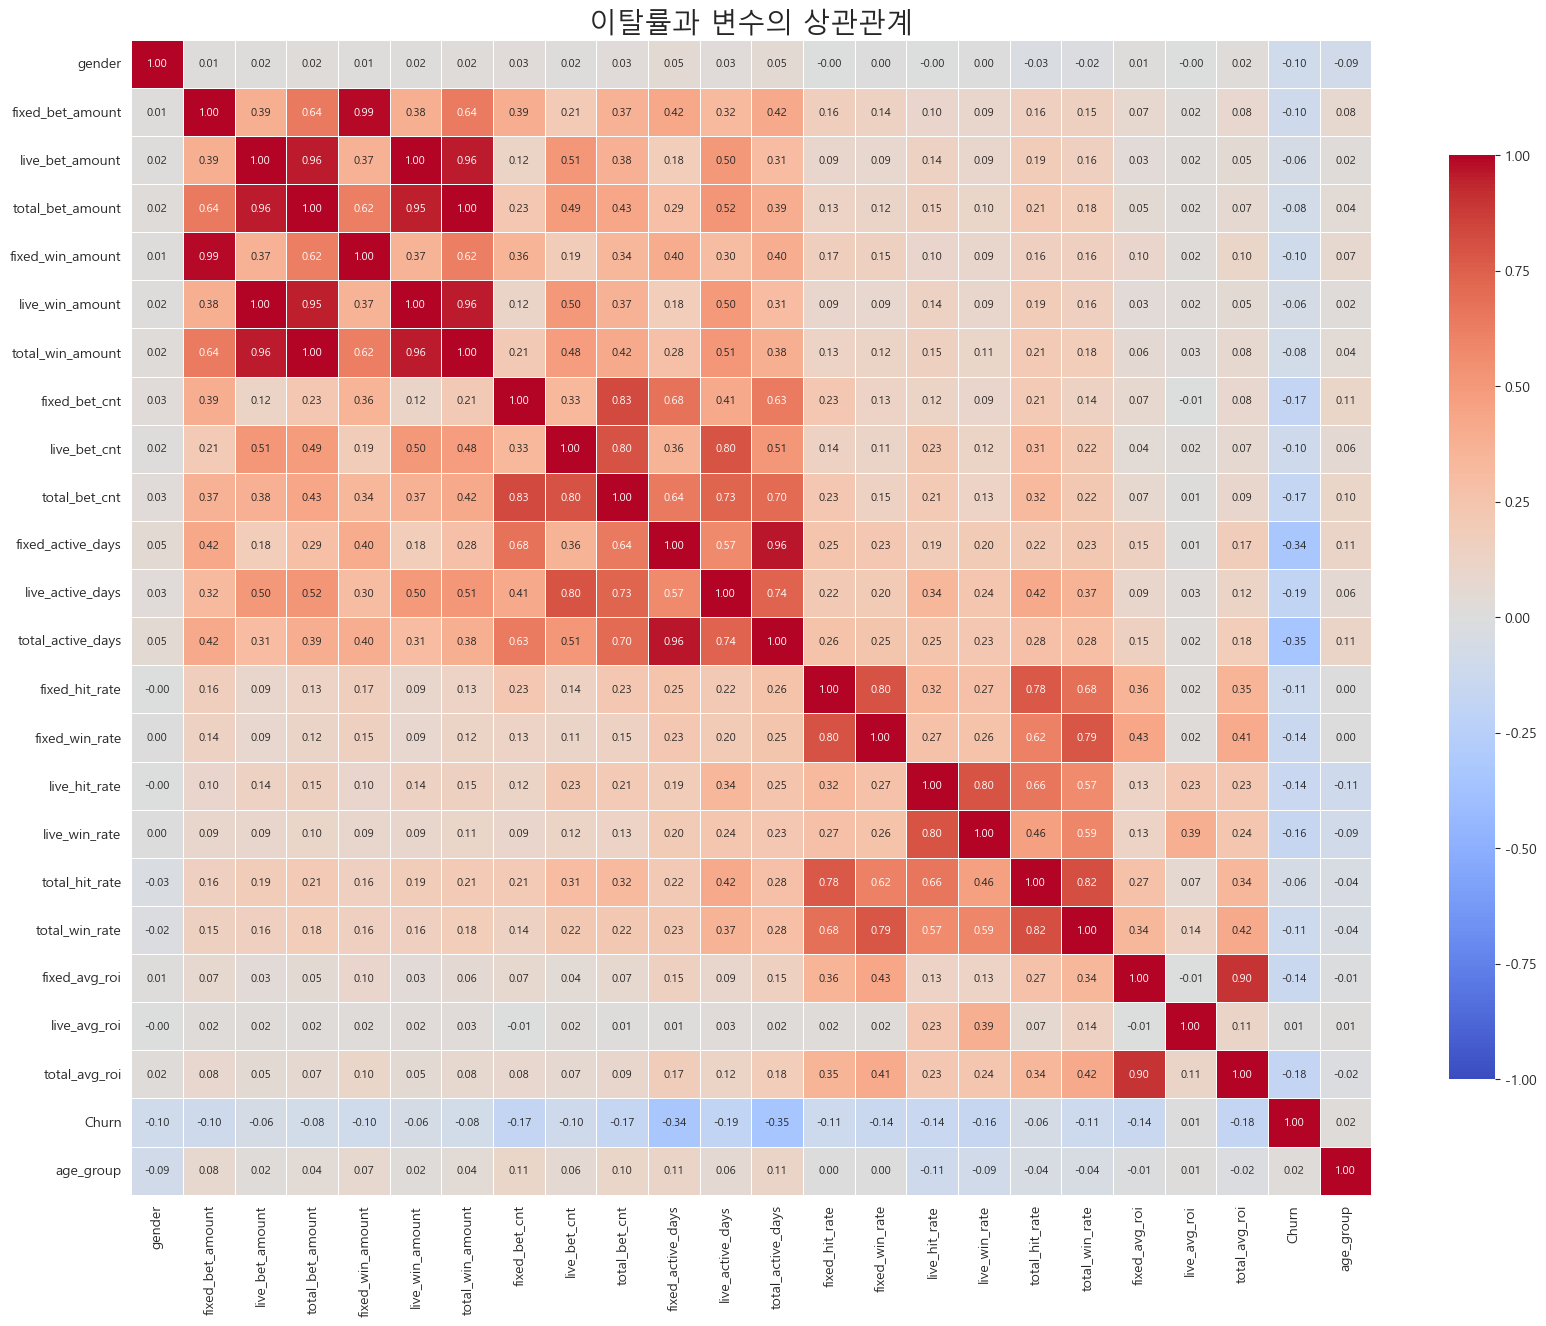

In [185]:
# 상관관계 히트맵

sports_gb_total['gender'] = sports_gb_total['gender'].astype(int)
sports_gb_total['Churn'] = sports_gb_total['Churn'].astype(int)

# 2. 숫자형 데이터만 추출하고 의미 없는 ID 열 제외
corr_df = sports_gb_total.select_dtypes(include=['number']).drop(columns=['user_id', 'country_id'], errors='ignore')

# 3. 상관계수 행렬 계산
corr = corr_df.corr()

# 4. 상삼각형 마스크 생성 (중복되는 반쪽을 가려줍니다)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 5. 히트맵 그리기
plt.figure(figsize=(20, 15))  # 변수가 많으므로 크기를 매우 크게 설정
sns.heatmap(corr, 
            annot=True,        # 숫자 표시
            fmt=".2f",         # 소수점 둘째자리
            cmap='coolwarm',   # 빨강(양), 파랑(음) 색상
            vmin=-1, vmax=1,   # 범위를 -1 ~ 1로 고정
            center=0,          # 중앙값 0 기준
            linewidths=.5,     # 칸 사이 간격
            cbar_kws={"shrink": .8}, # 범례 크기 조절
            annot_kws={"size": 8})   # 글자 크기 조절

plt.title('이탈률과 변수의 상관관계', fontsize=20)
plt.show()

In [186]:
# 3일 이상 유저수  확인 (일회성 유저 필터 역할)
# 3일 미만 유저가 기대만큼 많지않음

engaged_users = sports_gb_total[sports_gb_total['total_active_days'] >= 3].copy()

print(f"전체 유저 수: {len(sports_gb_total)}")
print(f"3일 이상 활동 유저 수: {len(engaged_users)}")
print(f"필터링 후 생존 유저 비율: {len(engaged_users)/len(sports_gb_total)*100:.1f}%")

전체 유저 수: 46337
3일 이상 활동 유저 수: 41772
필터링 후 생존 유저 비율: 90.1%


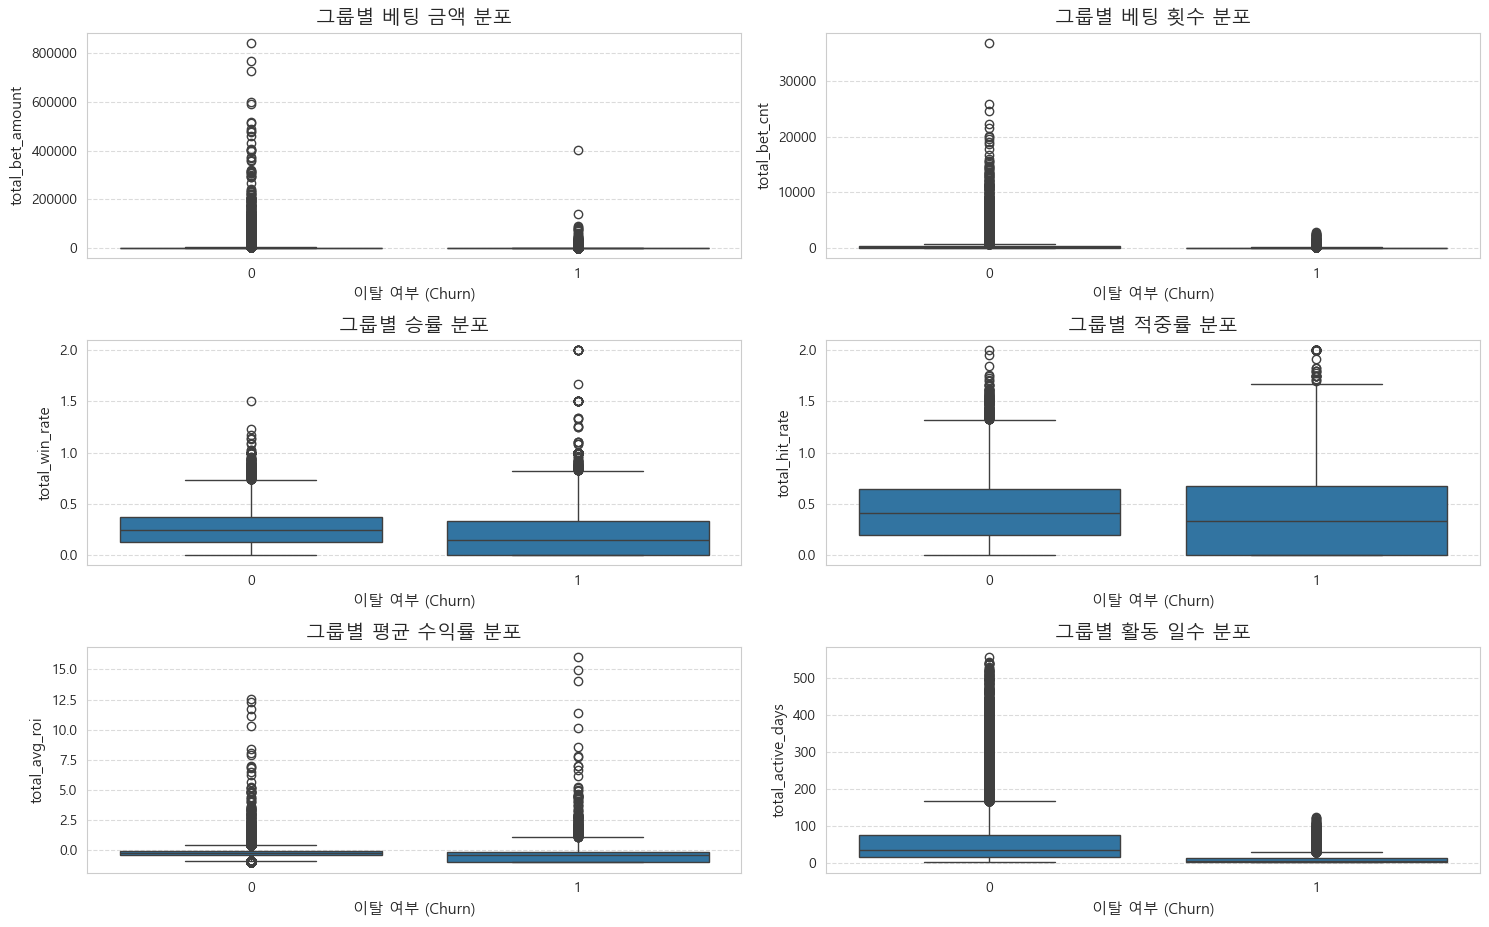

In [187]:
# 1. 시각화할 주요 변수 선택
features = ['total_bet_amount', 'total_bet_cnt', 'total_win_rate','total_hit_rate','total_avg_roi','total_active_days']
names = ['그룹별 베팅 금액 분포', '그룹별 베팅 횟수 분포', '그룹별 승률 분포', '그룹별 적중률 분포', '그룹별 평균 수익률 분포', '그룹별 활동 일수 분포']
# 2. 여러 개의 그래프를 한 번에 그리기
plt.figure(figsize=(15, 12))

for i, col in enumerate(features):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x='Churn', y=col, data=sports_gb_total)
    plt.title(f'{names[i]}', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xlabel('이탈 여부 (Churn)', fontsize=11)
    plt.ylabel(col, fontsize=11)

plt.tight_layout()
plt.show()

<Axes: xlabel='gender', ylabel='count'>

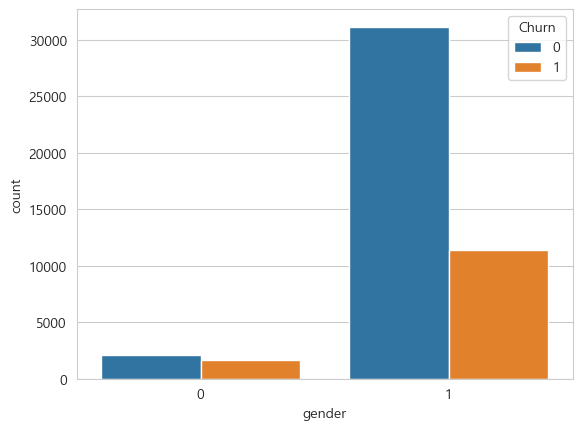

In [188]:
# 성별 그룹별 이탈 횟수
sns.countplot(x='gender', hue='Churn', data=sports_gb_total)

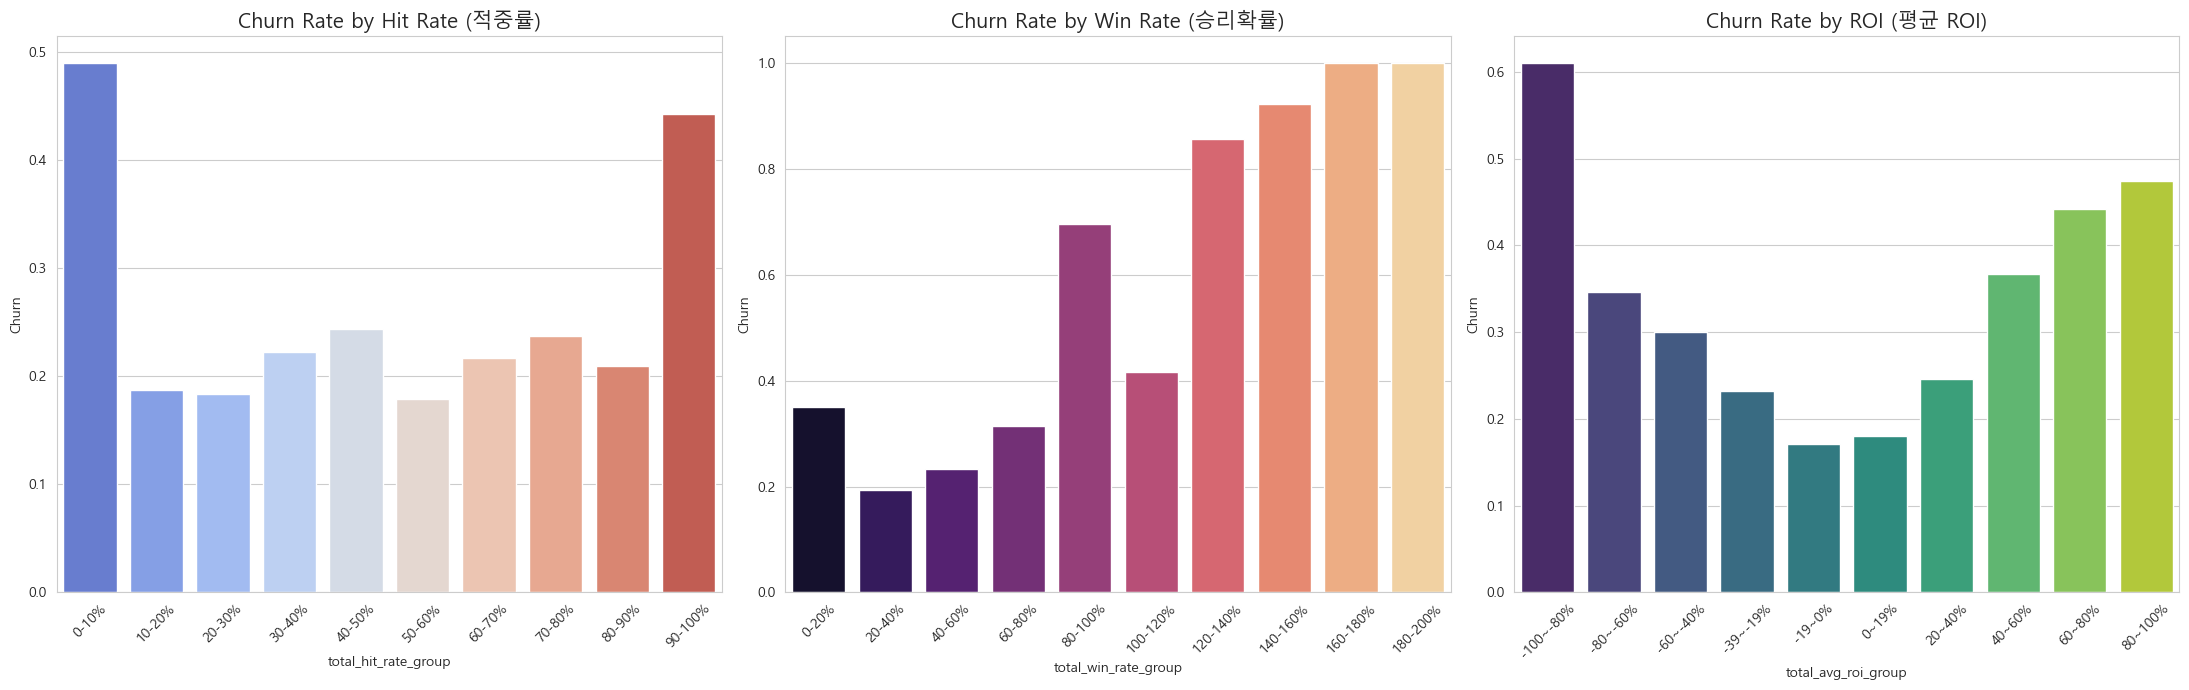

In [189]:
# 1. 구간 이름 정의 함수 (기존과 동일)
def get_labeled_churn_rate(df, column, bins, labels):
    df[f'{column}_group'] = pd.cut(df[column], bins=bins, labels=labels, include_lowest=True)
    group_churn = df.groupby(f'{column}_group', observed=True)['Churn'].mean().reset_index()
    return group_churn

# 2. 라벨 정의
# 공통 10개 구간 라벨 (필요시 각 변수마다 따로 정의 가능)
group_labels = [f'{i*10}-{(i+1)*10}%' for i in range(10)]

plt.figure(figsize=(22, 7))

# --- (1) 적중률 (Total Hit Rate) ---
plt.subplot(1, 3, 1) # 1행 3열 중 1번째
hit_bins = [0.1 * i for i in range(11)]
hit_churn_data = get_labeled_churn_rate(sports_gb_total, 'total_hit_rate', hit_bins, group_labels)
sns.barplot(x='total_hit_rate_group', y='Churn', data=hit_churn_data, palette='coolwarm')
plt.title('Churn Rate by Hit Rate (적중률)', fontsize=15)
plt.xticks(rotation=45)

# --- (2) 승리확률 (Total Win Rate) ---
plt.subplot(1, 3, 2) # 1행 3열 중 2번째
win_bins = [0.2 * i for i in range(11)]
win_labels = [f'{i*20}-{(i+1)*20}%' for i in range(10)]
temp_win_df = sports_gb_total[sports_gb_total['total_win_rate'] <= 2].copy()
win_churn_data = get_labeled_churn_rate(temp_win_df, 'total_win_rate', win_bins, win_labels)
sns.barplot(x='total_win_rate_group', y='Churn', data=win_churn_data, palette='magma')
plt.title('Churn Rate by Win Rate (승리확률)', fontsize=15)
plt.xticks(rotation=45)

# --- (3) ROI (Total Avg ROI) ---
plt.subplot(1, 3, 3) # 1행 3열 중 3번째
# ROI는 -1.0(-100%)부터 시작하는 경우가 많아 범위를 -1 ~ 1 정도로 잡습니다.
roi_bins = [-1.0 + 0.2 * i for i in range(11)]
roi_labels = [f'{int((-1.0 + 0.2 * i)*100)}~{int((-0.8 + 0.2 * i)*100)}%' for i in range(10)]
# 너무 극단적인 ROI는 제외하고 -100% ~ 100% 사이를 봅니다.
temp_roi_df = sports_gb_total[(sports_gb_total['total_avg_roi'] >= -1) & (sports_gb_total['total_avg_roi'] <= 1)].copy()
roi_churn_data = get_labeled_churn_rate(temp_roi_df, 'total_avg_roi', roi_bins, roi_labels)
sns.barplot(x='total_avg_roi_group', y='Churn', data=roi_churn_data, palette='viridis')
plt.title('Churn Rate by ROI (평균 ROI)', fontsize=15)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

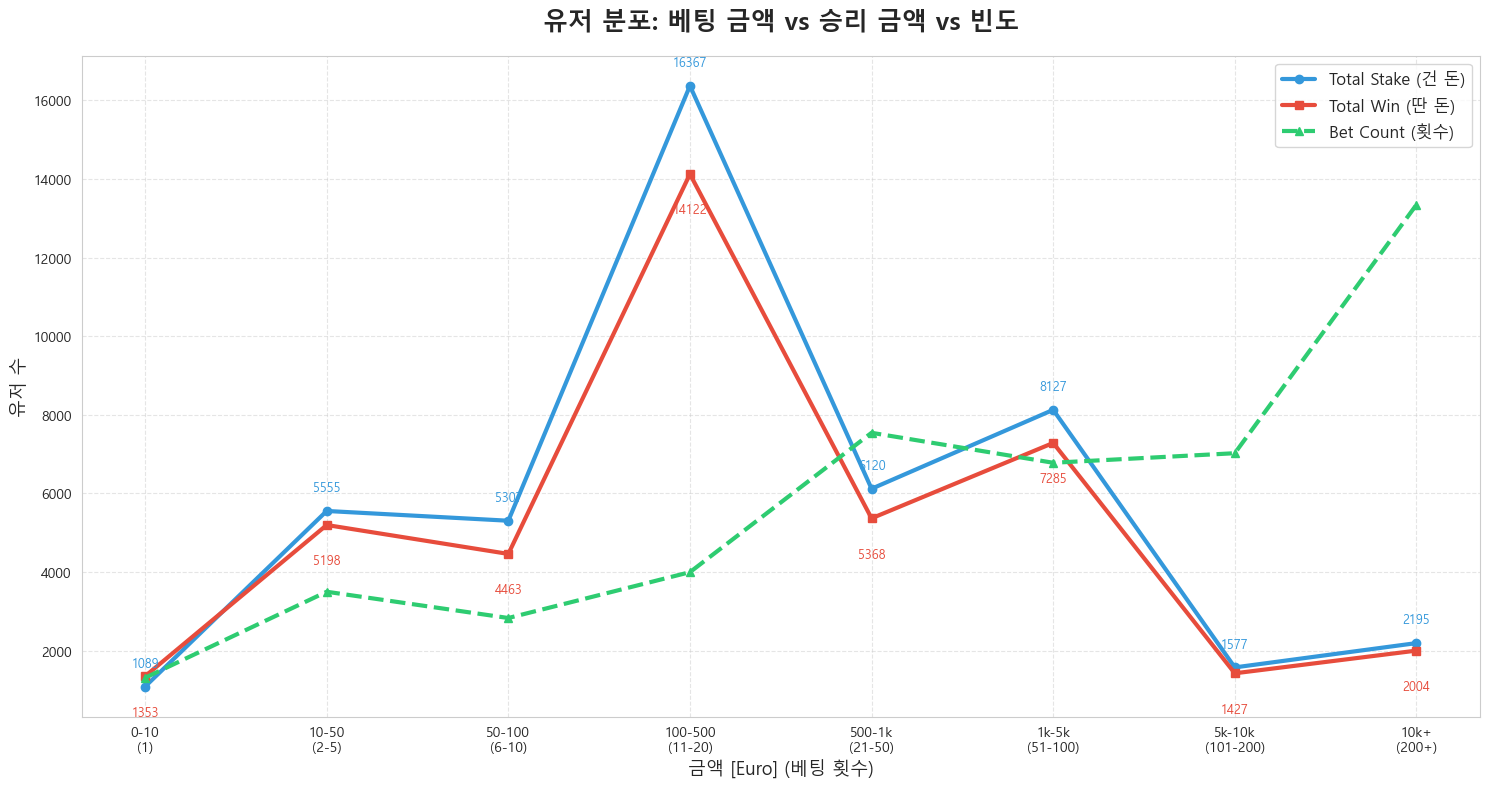

In [190]:
# 1. 구간 및 라벨 정의 (8개 그룹으로 통일)
amount_bins = [0, 10, 50, 100, 500, 1000, 5000, 10000, np.inf]
amount_labels = ['0-10', '10-50', '50-100', '100-500', '500-1k', '1k-5k', '5k-10k', '10k+']

cnt_bins = [0, 1, 5, 10, 20, 50, 100, 200, np.inf]
cnt_labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-200', '200+']

# 2. 구간별 유저 수 계산
stake_counts = pd.cut(sports_gb_total['total_bet_amount'], bins=amount_bins, labels=amount_labels).value_counts().sort_index()
win_counts = pd.cut(sports_gb_total['total_win_amount'], bins=amount_bins, labels=amount_labels).value_counts().sort_index()
cnt_counts = pd.cut(sports_gb_total['total_bet_cnt'], bins=cnt_bins, labels=cnt_labels).value_counts().sort_index()

# 3. 통합 데이터프레임 생성
# X축을 공통적으로 'Group 1~8'로 인식하게 하기 위해 인덱스를 활용합니다.
df_plot = pd.DataFrame({
    'Rank': range(1, 9),
    'Total Stake (Euro)': stake_counts.values,
    'Total Win (Euro)': win_counts.values,
    'Bet Count (Times)': cnt_counts.values
})

# 4. 시각화
plt.figure(figsize=(15, 8))

# 각 지표를 선 그래프로 표현
plt.plot(df_plot['Rank'], df_plot['Total Stake (Euro)'], marker='o', label='Total Stake (건 돈)', linewidth=3, color='#3498db')
plt.plot(df_plot['Rank'], df_plot['Total Win (Euro)'], marker='s', label='Total Win (딴 돈)', linewidth=3, color='#e74c3c')
plt.plot(df_plot['Rank'], df_plot['Bet Count (Times)'], marker='^', label='Bet Count (횟수)', linewidth=3, linestyle='--', color='#2ecc71')

# X축 라벨 설정 (금액과 횟수 라벨을 동시에 보여줌)
combined_labels = [f"{a}\n({c})" for a, c in zip(amount_labels, cnt_labels)]
plt.xticks(df_plot['Rank'], combined_labels, fontsize=10)

plt.title('유저 분포: 베팅 금액 vs 승리 금액 vs 빈도', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('유저 수', fontsize=13)
plt.xlabel('금액 [Euro] (베팅 횟수)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 값 표시 (선택 사항: 데이터 포인트 위에 숫자 표시)
for i, row in df_plot.iterrows():
    plt.text(row['Rank'], row['Total Stake (Euro)']+500, f"{int(row['Total Stake (Euro)'])}", ha='center', color='#3498db', fontsize=9)
    plt.text(row['Rank'], row['Total Win (Euro)']-1000, f"{int(row['Total Win (Euro)'])}", ha='center', color='#e74c3c', fontsize=9)

plt.tight_layout()
plt.show()

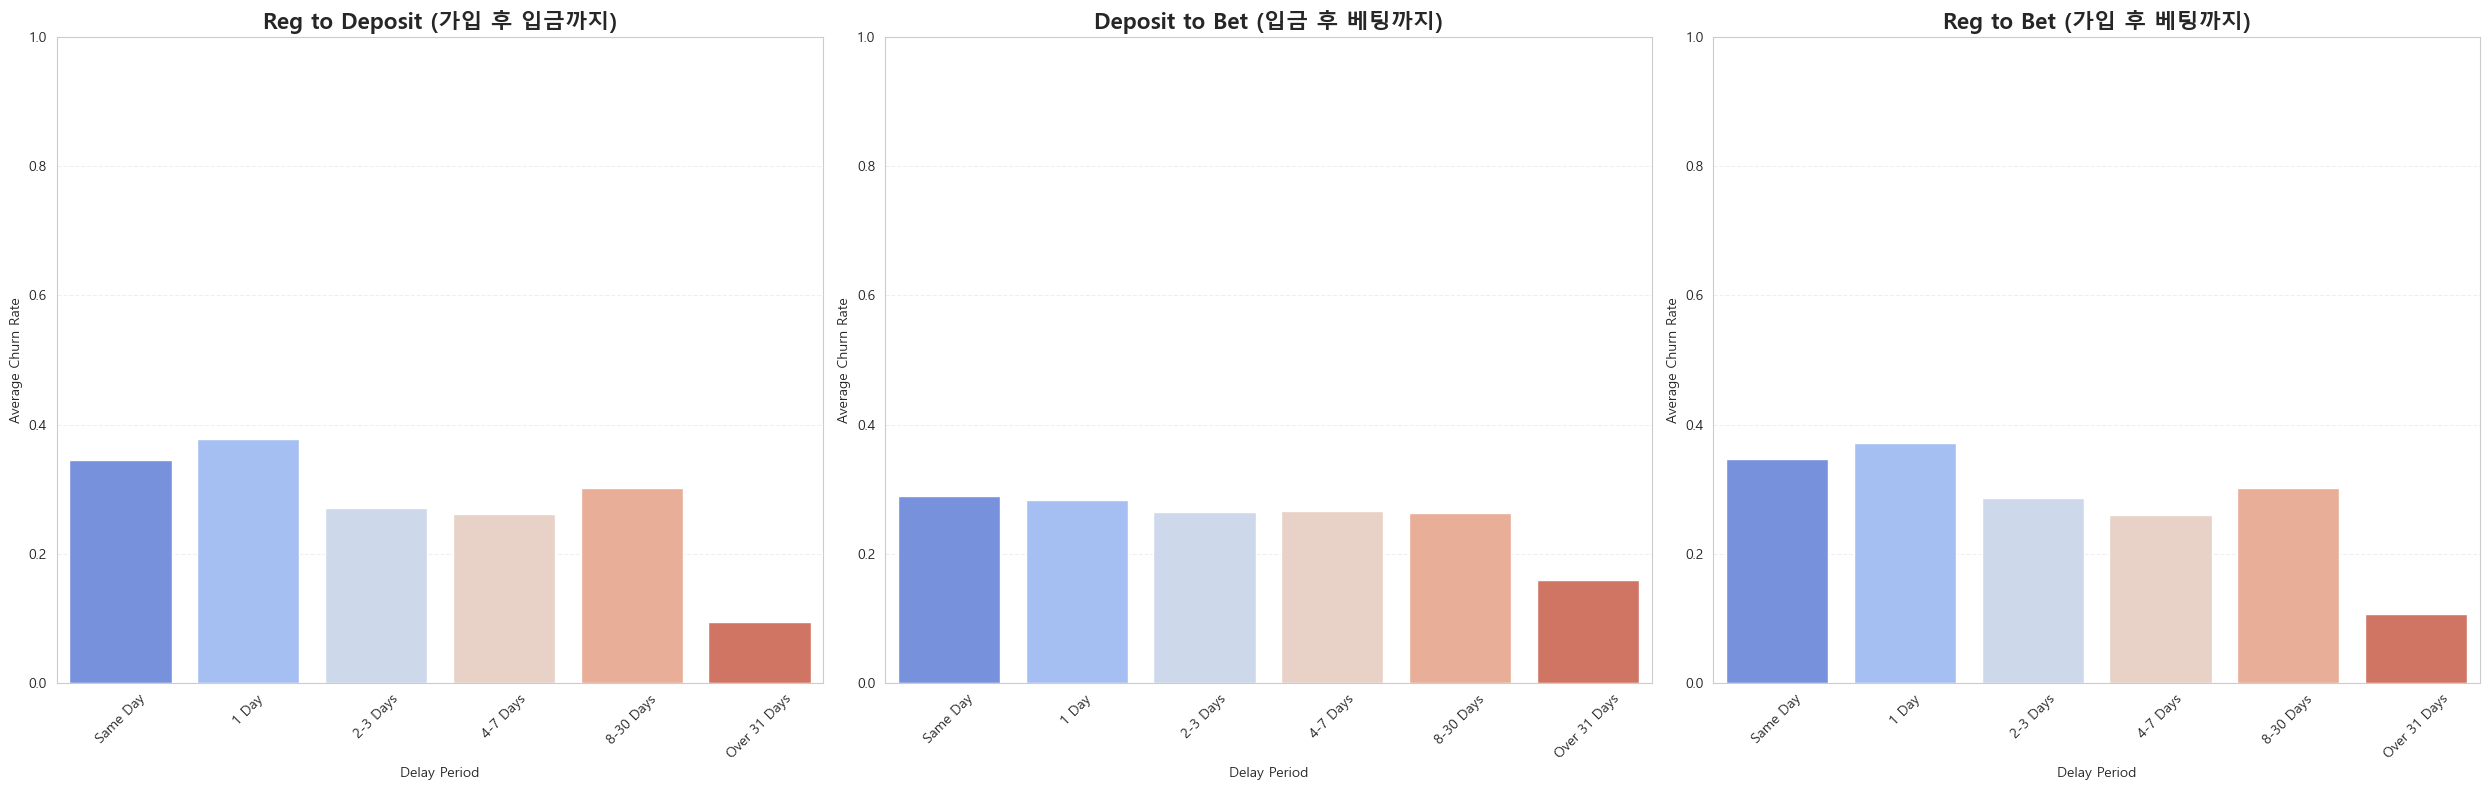

In [191]:
# 1. 날짜 차이(Delay) 계산 (단위: 일)
# .dt.days를 사용해 순수 날짜 차이만 추출합니다.
sports_gb_total['delay_reg_to_deposit'] = (sports_gb_total['first_deposit'] - sports_gb_total['reg_date']).dt.days
sports_gb_total['delay_deposit_to_bet'] = (sports_gb_total['first_bet'] - sports_gb_total['first_deposit']).dt.days
sports_gb_total['delay_reg_to_bet'] = (sports_gb_total['first_bet'] - sports_gb_total['reg_date']).dt.days

# 2. 분석하기 편하도록 날짜 구간(Binning) 정의
# 0일(당일), 1일, 2-3일, 4-7일, 8-30일, 31일 이상으로 나눕니다.
bins = [-1, 0, 1, 3, 7, 30, 999]
labels = ['Same Day', '1 Day', '2-3 Days', '4-7 Days', '8-30 Days', 'Over 31 Days']

# 3. 그래프 설정 (1행 3열)
plt.figure(figsize=(25, 8))

timeline_features = ['delay_reg_to_deposit', 'delay_deposit_to_bet', 'delay_reg_to_bet']
titles = ['Reg to Deposit (가입 후 입금까지)', 
          'Deposit to Bet (입금 후 베팅까지)', 
          'Reg to Bet (가입 후 베팅까지)']

for i, col in enumerate(timeline_features):
    plt.subplot(1, 3, i+1)
    
    # 구간 나누기
    group_col = f'{col}_group'
    sports_gb_total[group_col] = pd.cut(sports_gb_total[col], bins=bins, labels=labels)
    
    # 그룹별 Churn 평균 계산
    plot_data = sports_gb_total.groupby(group_col, observed=True)['Churn'].mean().reset_index()
    
    # 시각화
    sns.barplot(x=group_col, y='Churn', data=plot_data, palette='coolwarm')
    
    plt.title(titles[i], fontsize=16, fontweight='bold')
    plt.ylabel('Average Churn Rate')
    plt.xlabel('Delay Period')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

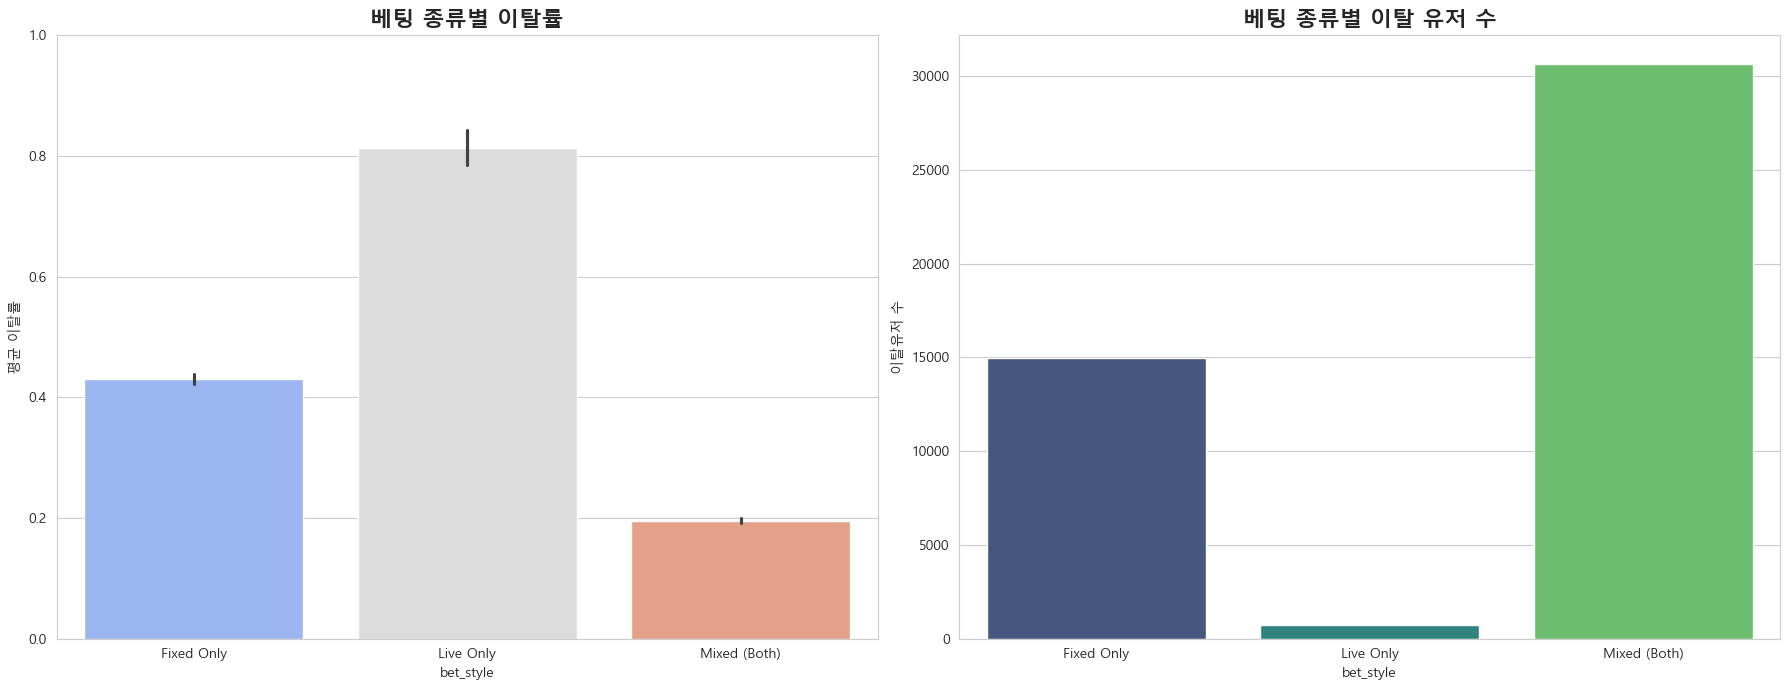

In [192]:
# 1. 유저 베팅 성향 그룹화 함수
def get_bet_type_group(row):
    if row['fixed_bet_amount'] > 0 and row['live_bet_amount'] == 0:
        return 'Fixed Only'
    elif row['fixed_bet_amount'] == 0 and row['live_bet_amount'] > 0:
        return 'Live Only'
    elif row['fixed_bet_amount'] > 0 and row['live_bet_amount'] > 0:
        return 'Mixed (Both)'
    else:
        return 'No Bet Record'

# 2. 그룹 생성 및 Churn 수치화
sports_gb_total['bet_style'] = sports_gb_total.apply(get_bet_type_group, axis=1)
sports_gb_total['Churn_int'] = sports_gb_total['Churn'].astype(int) 

# 3. 시각화 (그룹별 이탈률 & 그룹별 유저 수)
plt.figure(figsize=(18, 7))

# --- (좌) 그룹별 이탈률 평균 ---
plt.subplot(1, 2, 1)
sns.barplot(x='bet_style', y='Churn_int', data=sports_gb_total, 
            order=['Fixed Only', 'Live Only', 'Mixed (Both)'], palette='coolwarm')
plt.title('베팅 종류별 이탈률', fontsize=16, fontweight='bold')
plt.ylabel('평균 이탈률')
plt.ylim(0, 1.0)

# --- (우) 그룹별 실제 유저 수 ---
plt.subplot(1, 2, 2)
sns.countplot(x='bet_style', data=sports_gb_total, 
              order=['Fixed Only', 'Live Only', 'Mixed (Both)'], palette='viridis')
plt.title('베팅 종류별 이탈 유저 수', fontsize=16, fontweight='bold')
plt.ylabel('이탈유저 수')

plt.tight_layout()
plt.show()

In [193]:
df_F = pd.read_csv('../../data/raw/sports_gb_F.csv')
df_L = pd.read_csv('../../data/raw/sports_gb_L.csv')

# StakeF가 0이 아닌 행들만 골라서 다시 저장
df_F = df_F[df_F['StakeF'] != 0]

# StakeL이 0이 아닌 행들만 골라서 다시 저장
df_L = df_L[df_L['StakeL'] != 0]

In [194]:
df_final = df_final.rename(columns={'user_id': 'UserID'})

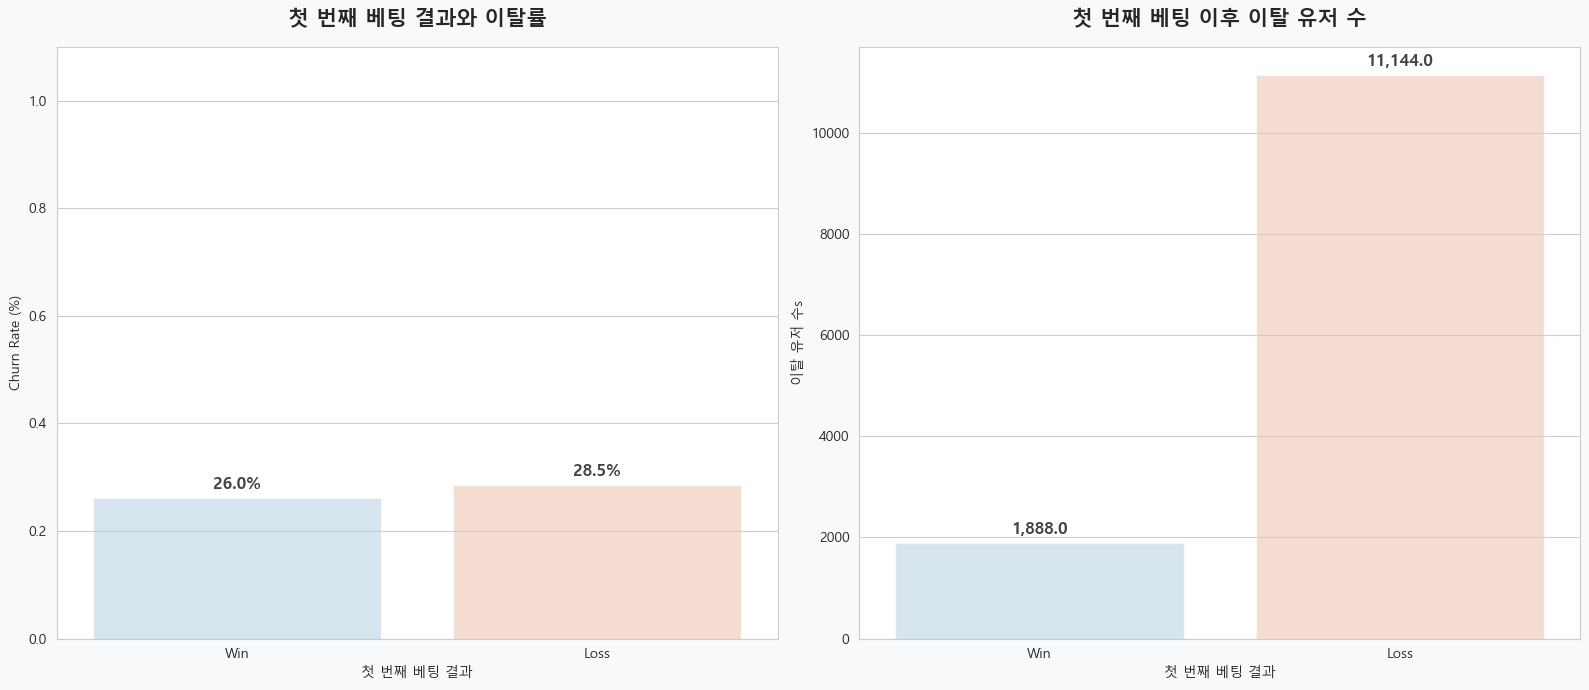

--- 첫 베팅 결과별 이탈률 통계 ---
첫 번째 베팅 결과
Loss    0.28510
Win     0.26045
Name: Churn, dtype: float64


In [195]:
# 1. 데이터 통합 및 이름 통일
f_temp = df_F[['UserID', 'DateBet', 'StakeF', 'WinF']].copy()
f_temp.columns = ['UserID', 'DateBet', 'Stake', 'Win']

l_temp = df_L[['UserID', 'DateBet', 'StakeL', 'WinL']].copy()
l_temp.columns = ['UserID', 'DateBet', 'Stake', 'Win']

df_combined = pd.concat([f_temp, l_temp], axis=0)
df_combined['DateBet'] = pd.to_datetime(df_combined['DateBet'])

# 2. 유저별 '진짜 첫 번째' 베팅 기록 추출
df_absolute_first = df_combined.sort_values(by=['UserID', 'DateBet']).groupby('UserID').first().reset_index()

# 3. 성적 정의 (Win / Loss)
df_absolute_first['첫 번째 베팅 결과'] = df_absolute_first.apply(
    lambda x: 'Win' if x['Win'] > x['Stake'] else 'Loss', axis=1
)

# 4. df_final의 Churn 정보와 결합
df_analysis = pd.merge(
    df_absolute_first[['UserID', '첫 번째 베팅 결과', 'DateBet']], 
    df_final[['UserID', 'Churn']], 
    on='UserID'
)

# 5. 시각화
plt.figure(figsize=(16, 7), facecolor='#f8f9fa')

# --- (좌) 진짜 첫 베팅 결과에 따른 이탈률 (%) ---
plt.subplot(1, 2, 1)
# alpha=0.5로 연하게, RdBu_r 적용
ax1 = sns.barplot(x='첫 번째 베팅 결과', y='Churn', data=df_analysis, 
                  palette='RdBu_r', ci=None, alpha=0.5, order=['Win', 'Loss'])

# 막대 위에 이탈률 % 표시
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.1%'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, 10), textcoords = 'offset points',
                 fontsize=12, fontweight='bold', color='#444444')

plt.title('첫 번째 베팅 결과와 이탈률', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 1.1)

# --- (우) ★ 이탈자(Churn=1) 중 첫 베팅 결과 분포 ★ ---
plt.subplot(1, 2, 2)
# 이탈자만 필터링하여 카운트 플롯 생성
churned_only = df_analysis[df_analysis['Churn'] == 1]
ax2 = sns.countplot(x='첫 번째 베팅 결과', data=churned_only, 
                    palette='RdBu_r', alpha=0.5, order=['Win', 'Loss'])

# 막대 위에 이탈 유저 수(명) 표시
for p in ax2.patches:
    ax2.annotate(format(p.get_height(), ','), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, 10), textcoords = 'offset points',
                 fontsize=12, fontweight='bold', color='#444444')

plt.title('첫 번째 베팅 이후 이탈 유저 수', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('이탈 유저 수s')

plt.tight_layout()
plt.show()

# 상세 수치 출력
print("--- 첫 베팅 결과별 이탈률 통계 ---")
print(df_analysis.groupby('첫 번째 베팅 결과')['Churn'].mean())

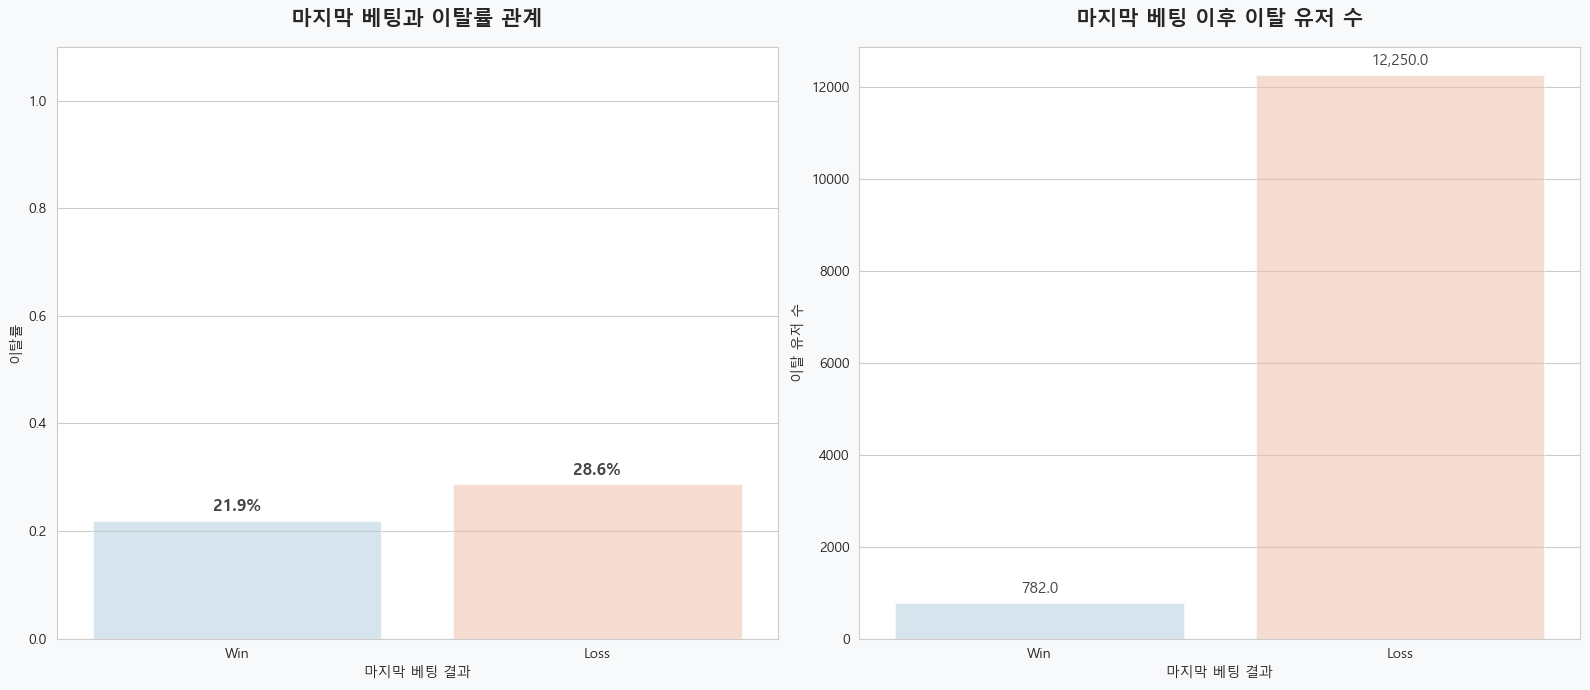

--- 마지막 베팅 결과별 이탈률 통계 ---
마지막 베팅 결과
Loss    0.286456
Win     0.218864
Name: Churn, dtype: float64


In [196]:
# 1. 데이터 통합 및 이름 통일 (F, L 소스 합치기)
f_last = df_F[['UserID', 'DateBet', 'StakeF', 'WinF']].copy()
f_last.columns = ['UserID', 'DateBet', 'Stake', 'Win']

l_last = df_L[['UserID', 'DateBet', 'StakeL', 'WinL']].copy()
l_last.columns = ['UserID', 'DateBet', 'Stake', 'Win']

df_combined_last = pd.concat([f_last, l_last], axis=0)
df_combined_last['DateBet'] = pd.to_datetime(df_combined_last['DateBet'])

# 2. 유저별 '절대적 마지막 베팅' 기록 추출 (기록이 있는 유저들만 남음)
df_absolute_last = df_combined_last.sort_values(by=['UserID', 'DateBet']).groupby('UserID').last().reset_index()

# 3. 마지막 베팅 성적 정의 (Win / Loss)
df_absolute_last['마지막 베팅 결과'] = df_absolute_last.apply(
    lambda x: 'Win' if x['Win'] > x['Stake'] else 'Loss', axis=1
)

# 4. df_final의 Churn 정보와 결합 (Inner Join으로 베팅 미수행자 제외)
df_last_analysis = pd.merge(
    df_absolute_last[['UserID', '마지막 베팅 결과']], 
    df_final[['UserID', 'Churn']], 
    on='UserID'
)

# 5. 시각화
plt.figure(figsize=(16, 7), facecolor='#f8f9fa')

# --- (좌) 마지막 베팅 결과에 따른 이탈률 (%) ---
plt.subplot(1, 2, 1)
# alpha=0.5와 RdBu_r로 연하고 직관적인 색감 적용
ax1 = sns.barplot(x='마지막 베팅 결과', y='Churn', data=df_last_analysis, 
                  palette='RdBu_r', ci=None, alpha=0.5, order=['Win', 'Loss'])

for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.1%'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, 10), textcoords = 'offset points',
                 fontsize=12, fontweight='bold', color='#444444')

plt.title('마지막 베팅과 이탈률 관계', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('이탈률')
plt.ylim(0, 1.1)

# --- (우) 이탈자(Churn=1) 중 마지막 베팅 결과 분포 ---
plt.subplot(1, 2, 2)
churned_only = df_last_analysis[df_last_analysis['Churn'] == 1]
ax2 = sns.countplot(x='마지막 베팅 결과', data=churned_only, 
                   palette='RdBu_r', alpha=0.5, order=['Win', 'Loss'])

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), ','), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, 10), textcoords = 'offset points',
                 fontsize=11, color='#444444')

plt.title('마지막 베팅 이후 이탈 유저 수', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('이탈 유저 수')

plt.tight_layout()
plt.show()

# 상세 수치 출력
print("--- 마지막 베팅 결과별 이탈률 통계 ---")
print(df_last_analysis.groupby('마지막 베팅 결과')['Churn'].mean())

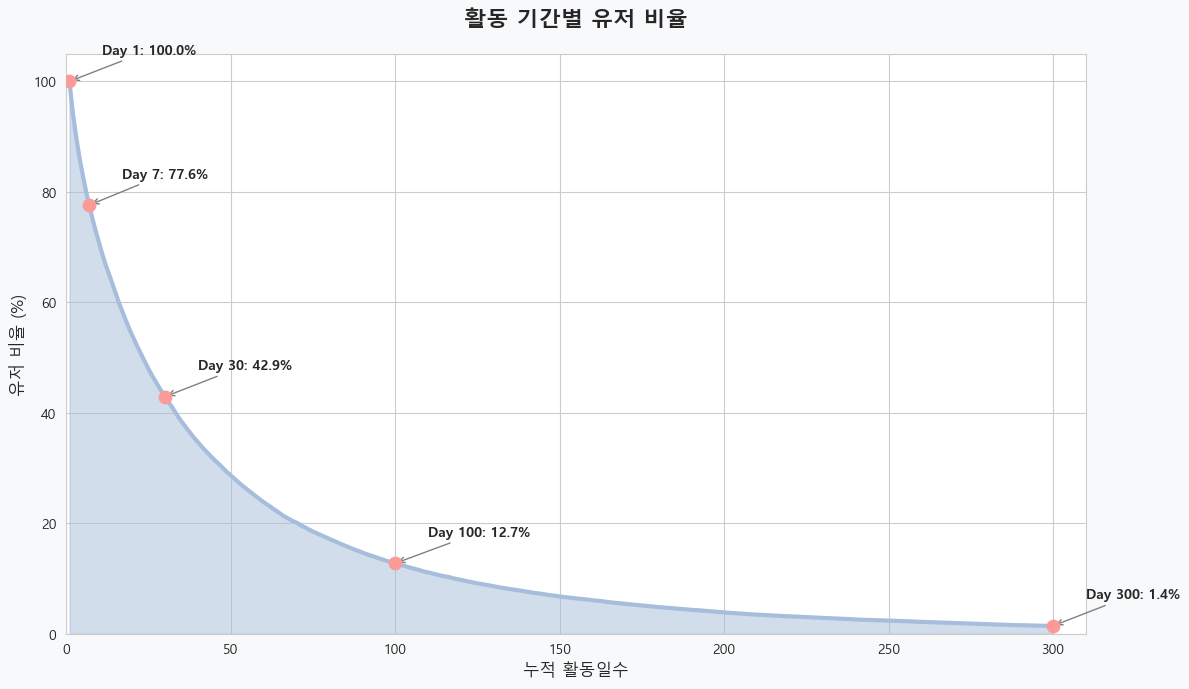

In [198]:
# 1. 스타일 및 폰트 설정 (이전 설정 유지)
plt.figure(figsize=(12, 7), facecolor='#f8f9fa')

# 2. DaysA(실제 활동일수) 데이터 추출 및 300일 제한 리텐션 계산
# 1일부터 300일까지 각 일자별 잔존율 계산
total_users = len(df_final)
retention_data = []

# 최대 범위를 300으로 제한
target_range = min(300, int(df_final['DaysA'].max()))

for i in range(1, target_range + 1):
    remaining_users = len(df_final[df_final['DaysA'] >= i])
    retention_rate = (remaining_users / total_users) * 100
    retention_data.append({'Day': i, 'Retention_Rate': retention_rate})

df_retention_300 = pd.DataFrame(retention_data)

# 3. 시각화 (연한 파스텔톤 반영)
plt.plot(df_retention_300['Day'], df_retention_300['Retention_Rate'], 
         color='#a6bddb', linewidth=3, label='잔존율(%)')
plt.fill_between(df_retention_300['Day'], df_retention_300['Retention_Rate'], 
                 color='#a6bddb', alpha=0.5)

# 4. 주요 변곡점 주석 (Day 1, 30, 100, 300 등)
check_points = [1, 7, 30, 100, 300]
for day in check_points:
    if day <= target_range:
        rate = df_retention_300.loc[df_retention_300['Day'] == day, 'Retention_Rate'].values[0]
        plt.scatter(day, rate, color='#fb9a99', s=80, zorder=5)
        plt.annotate(f'Day {day}: {rate:.1f}%', 
                     xy=(day, rate), xytext=(day+10, rate+5),
                     arrowprops=dict(arrowstyle='->', color='gray'),
                     fontsize=10, fontweight='bold')

# 5. 그래프 세부 설정
plt.title('활동 기간별 유저 비율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('누적 활동일수', fontsize=12)
plt.ylabel('유저 비율 (%)', fontsize=12)
plt.xlim(0, 310) 
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

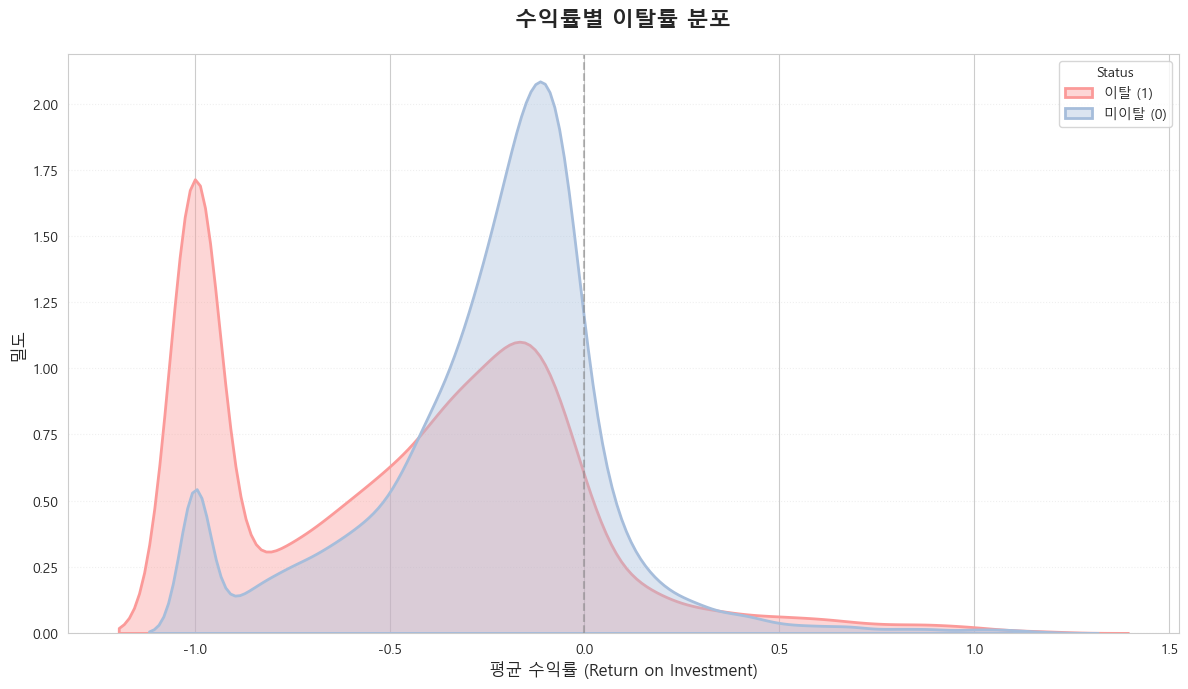

In [202]:
# 1. ROI 분포 시각화 (이상치 제외: -1.0 ~ 1.0 구간 집중)
# ROI가 -1 미만(100% 초과 손실)이거나 1 초과인 극단적 케이스는 
# 그래프의 가독성을 위해 범위를 제한하여 그리는 것이 좋습니다.
plt.figure(figsize=(12, 7))

# 연한 파스텔 톤 설정 (Light Blue: 유지자, Light Red: 이탈자)
palette = {0: "#a6bddb", 1: "#fb9a99"} 

# KDE Plot (커널 밀도 추정 그래프)로 분포 비교
sns.kdeplot(data=df_final[(df_final['total_avg_roi'] >= -1.2) & (df_final['total_avg_roi'] <= 1.2)], 
            x='total_avg_roi', 
            hue='Churn', 
            fill=True, 
            common_norm=False, 
            palette=palette, 
            alpha=0.4, # 연하게 표현하기 위해 투명도 조절
            linewidth=2)

# 기준선 표시 (ROI 0: 본전)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Break-even')

plt.title('수익률별 이탈률 분포', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('평균 수익률 (Return on Investment)', fontsize=12)
plt.ylabel('밀도', fontsize=12)

# 범례 이름 변경
plt.legend(title='Status', labels=['이탈 (1)', '미이탈 (0)'])

plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()